# ONDOUSDC Depletion Bias Prediction

This notebook asks a narrow question: can a past-only depletion-bias feature help predict short-horizon midprice moves?

It uses the shared ONDOUSDC split from the layer-depletion study:

- train: `20260226`, `20260227`
- validation: `20260228`

The main feature is `depletion_bias`, with `top_imbalance` as the baseline comparison.

## Feature Definitions

The feature side is built from a trailing book window, using only information available at or before time `t`.

- `bid_depletion_rate`: recent bid-side shrinkage divided by visible bid depth
- `ask_depletion_rate`: recent ask-side shrinkage divided by visible ask depth
- `depletion_bias = ask_depletion_rate - bid_depletion_rate`
- `top_imbalance = (bid1_qty - ask1_qty) / (bid1_qty + ask1_qty)`

Targets are forward log returns on a 1-second grid:

- `1s`
- `2s`
- `3s`

The baseline question is whether `depletion_bias` adds anything beyond `top_imbalance`.

In [1]:
from __future__ import annotations

from pathlib import Path
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def load_notebook_utils(start: Path | None = None):
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        utils_path = candidate / 'notebooks' / 'notebook_utils.py'
        if utils_path.is_file():
            spec = importlib.util.spec_from_file_location('notebook_utils', utils_path)
            if spec is None or spec.loader is None:
                raise ImportError(f'Could not load notebook utilities from {utils_path}')
            module = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(module)
            return module
    raise FileNotFoundError('Could not locate notebooks/notebook_utils.py')


notebook_utils = load_notebook_utils()
PROJECT_ROOT = notebook_utils.bootstrap_backtester_path()

from stats.features import forward_returns, trades_to_bars
from stats.notebook import load_orderflow_day

print(f'PROJECT_ROOT = {PROJECT_ROOT}')

PROJECT_ROOT = /Users/hoangdeveloper/PycharmProjects/exchange-data-backtester


In [2]:
SYMBOL = 'ONDOUSDC'
DAY_SPLITS = {
    'train': ['20260226', '20260227'],
    'valid': ['20260228'],
}
REPLAY_ON_GAP = 'skip-segment'
GRID_FREQ = '1s'
DEPLETION_WINDOW = '1s'
WINDOW_SWEEP = ['1s', '2s', '5s', '10s']
HORIZONS_MS = [1000, 2000, 3000]
TOP_IMBALANCE_EPS = 1e-9

FEATURE_SPECS = [
    ('depletion_bias', 'depletion_bias'),
    ('depletion_ratio', 'depletion_ratio'),
    ('depletion_acceleration', 'depletion_acceleration'),
    ('trade_flow_imbalance', 'trade_flow_imbalance'),
    ('quote_update_intensity', 'quote_update_intensity'),
    ('queue_survival_half_life_ms', 'queue_survival_half_life_ms'),
    ('queue_survival_bias_ms', 'queue_survival_bias_ms'),
    ('top_imbalance', 'top_imbalance'),
    ('ask_depletion_rate', 'ask_depletion_rate'),
    ('bid_depletion_rate', 'bid_depletion_rate'),
]

COMBINED_SPECS = [
    ('top+depletion_bias', ['top_imbalance', 'depletion_bias']),
    ('top+depletion_ratio', ['top_imbalance', 'depletion_ratio']),
    ('top+depletion_acceleration', ['top_imbalance', 'depletion_acceleration']),
    ('top+quote_update_intensity', ['top_imbalance', 'quote_update_intensity']),
    ('top+queue_survival_half_life_ms', ['top_imbalance', 'queue_survival_half_life_ms']),
    ('top+queue_survival_bias_ms', ['top_imbalance', 'queue_survival_bias_ms']),
    ('top+trade_flow_imbalance', ['top_imbalance', 'trade_flow_imbalance']),
    ('top+depletion_bias+spread', ['top_imbalance', 'depletion_bias', 'spread_bps']),
]
TARGET_COLS = [f'fwd_ret_{h}ms' for h in HORIZONS_MS]


In [3]:
def build_day_frame(day: str, split_name: str, *, depletion_window: str = DEPLETION_WINDOW) -> tuple[pd.DataFrame, pd.Series]:
    dataset, trades, top, summary = load_orderflow_day(
        day=day,
        symbol=SYMBOL,
        replay_on_gap=REPLAY_ON_GAP,
        project_root=PROJECT_ROOT,
    )

    required = ['ts', 'mid', 'bid1_price', 'ask1_price', 'bid1_qty', 'ask1_qty']
    missing = [c for c in required if c not in top.columns]
    if missing:
        raise KeyError(f'top is missing required columns: {missing}')

    book = top[required].dropna().copy()
    book['ts'] = pd.to_datetime(book['ts'], utc=True)
    book = book.sort_values('ts').set_index('ts').resample(GRID_FREQ).last().ffill()
    book['top_imbalance'] = (book['bid1_qty'] - book['ask1_qty']) / (
        book['bid1_qty'] + book['ask1_qty'] + TOP_IMBALANCE_EPS
    )
    book['spread'] = book['ask1_price'] - book['bid1_price']
    book['spread_bps'] = np.where(book['mid'] > 0, 1e4 * book['spread'] / book['mid'], np.nan)

    depletion = notebook_utils.build_top_depth_depletion_frame(
        top[['ts', 'bid1_qty', 'ask1_qty']].copy(),
        window=depletion_window,
    )
    depletion['ts'] = pd.to_datetime(depletion['ts'], utc=True)
    depletion = depletion.sort_values('ts').set_index('ts').resample(GRID_FREQ).last().ffill()

    quote_update_window_ns = int(pd.Timedelta(GRID_FREQ).value)
    top_updates = top[['ts']].dropna().copy()
    top_updates['ts'] = pd.to_datetime(top_updates['ts'], utc=True)
    top_updates = top_updates.sort_values('ts').reset_index(drop=True)
    top_update_ns = top_updates['ts'].astype('int64').to_numpy(dtype=np.int64)
    quote_update_count = notebook_utils.rolling_time_window_sum(
        top_update_ns,
        np.ones(len(top_updates), dtype=float),
        top_update_ns,
        quote_update_window_ns,
    )
    quote_updates = pd.DataFrame({'ts': top_updates['ts'], 'quote_update_intensity': quote_update_count})
    quote_updates = quote_updates.set_index('ts').resample(GRID_FREQ).last().ffill()

    survival = notebook_utils.build_top_price_survival_frame(top[['ts', 'bid1_price', 'ask1_price']].copy())
    survival['ts'] = pd.to_datetime(survival['ts'], utc=True)
    survival = survival.sort_values('ts').set_index('ts').resample(GRID_FREQ).last().ffill()

    trade_bars = trades_to_bars(trades, grid_freq=GRID_FREQ).rename(columns={'tfi_qty': 'trade_flow_imbalance'})
    trade_bars.index = pd.to_datetime(trade_bars.index, utc=True)
    trade_bars['trade_flow_imbalance'] = trade_bars['trade_flow_imbalance'].fillna(0.0)

    frame = book[['mid', 'top_imbalance', 'spread', 'spread_bps']].join(
        depletion[['bid_depletion_rate', 'ask_depletion_rate', 'depletion_bias']],
        how='left',
    )
    frame['depletion_ratio'] = frame['depletion_bias'] / (
        frame['ask_depletion_rate'] + frame['bid_depletion_rate'] + TOP_IMBALANCE_EPS
    )
    frame['depletion_acceleration'] = frame['depletion_bias'].diff()
    frame = frame.join(quote_updates[['quote_update_intensity']], how='left')
    frame['quote_update_intensity'] = frame['quote_update_intensity'].fillna(0.0)
    frame = frame.join(survival[['bid_price_age_ms', 'ask_price_age_ms', 'queue_survival_half_life_ms', 'queue_survival_bias_ms']], how='left')
    frame = frame.join(trade_bars[['trade_flow_imbalance']], how='left')
    frame['trade_flow_imbalance'] = frame['trade_flow_imbalance'].fillna(0.0)
    frame = frame.join(forward_returns(frame['mid'], horizons_ms=HORIZONS_MS, grid_freq=GRID_FREQ, log=True))
    frame = frame.dropna(subset=TARGET_COLS).reset_index()
    frame['day'] = day
    frame['split'] = split_name
    return frame, summary


def get_split_frame(day_records: list[dict], split_name: str) -> pd.DataFrame:
    return pd.concat([r['frame'] for r in day_records if r['split'] == split_name], ignore_index=True).copy()


def summarize_feature(frame: pd.DataFrame, *, feature_col: str, target_col: str) -> pd.Series:
    sub = frame[[feature_col, target_col]].dropna().copy()
    if sub.empty:
        return pd.Series({'n': 0, 'mean_return_bps': np.nan, 'pearson': np.nan, 'spearman': np.nan})
    x = sub[feature_col].to_numpy(dtype=float)
    y = sub[target_col].to_numpy(dtype=float)
    pearson = float(np.corrcoef(x, y)[0, 1]) if len(sub) > 1 and np.std(x) > 0 and np.std(y) > 0 else np.nan
    spearman = float(np.corrcoef(pd.Series(x).rank(method='average'), pd.Series(y).rank(method='average'))[0, 1]) if len(sub) > 1 and np.std(x) > 0 and np.std(y) > 0 else np.nan
    return pd.Series({
        'n': int(len(sub)),
        'mean_return_bps': float(np.mean(y) * 1e4),
        'pearson': pearson,
        'spearman': spearman,
    })


def fit_ols_beta(frame: pd.DataFrame, target_col: str, feature_cols: list[str]) -> np.ndarray:
    sub = frame[[target_col, *feature_cols]].dropna().copy()
    x = np.column_stack([np.ones(len(sub), dtype=float), sub[feature_cols].to_numpy(dtype=float)])
    y = sub[target_col].to_numpy(dtype=float)
    beta, *_ = np.linalg.lstsq(x, y, rcond=None)
    return beta


def ols_predict(frame: pd.DataFrame, target_col: str, feature_cols: list[str], beta: np.ndarray) -> tuple[pd.DataFrame, np.ndarray]:
    sub = frame[[target_col, *feature_cols]].dropna().copy()
    x = np.column_stack([np.ones(len(sub), dtype=float), sub[feature_cols].to_numpy(dtype=float)])
    pred = x @ beta
    return sub, pred


def ols_metrics(y_true: np.ndarray, pred: np.ndarray) -> dict[str, float]:
    mask = np.isfinite(y_true) & np.isfinite(pred)
    if not mask.any():
        return {'n': 0, 'r2': np.nan, 'pearson': np.nan, 'spearman': np.nan, 'hit_rate': np.nan}
    y = y_true[mask]
    p = pred[mask]
    if len(y) > 1 and np.std(y) > 0 and np.std(p) > 0:
        pearson = float(np.corrcoef(y, p)[0, 1])
        spearman = float(np.corrcoef(pd.Series(y).rank(method='average'), pd.Series(p).rank(method='average'))[0, 1])
        r2 = float(1.0 - np.sum((y - p) ** 2) / np.sum((y - y.mean()) ** 2))
    else:
        pearson = np.nan
        spearman = np.nan
        r2 = np.nan
    hit_rate = float(np.mean(np.sign(y) == np.sign(p)))
    return {'n': int(len(y)), 'r2': r2, 'pearson': pearson, 'spearman': spearman, 'hit_rate': hit_rate}


def bucket_curve(frame: pd.DataFrame, *, feature_col: str, target_col: str, q: int = 10) -> pd.DataFrame:
    sub = frame[[feature_col, target_col]].dropna().copy()
    if sub.empty:
        return pd.DataFrame(columns=['bucket', target_col])
    bucket_count = min(q, len(sub))
    sub['bucket'] = pd.qcut(sub[feature_col].rank(method='first'), q=bucket_count, labels=False, duplicates='drop')
    grp = sub.groupby('bucket', as_index=False)[target_col].mean().sort_values('bucket')
    grp['bucket'] = grp['bucket'] + 1
    return grp


In [4]:
day_records = []
day_summary_rows = []

for split_name, days in DAY_SPLITS.items():
    for day in days:
        frame, summary = build_day_frame(day, split_name)
        day_records.append({'day': day, 'split': split_name, 'frame': frame, 'summary': summary})
        day_summary_rows.append({
            'day': day,
            'split': split_name,
            'frame_rows': int(len(frame)),
            'trade_rows': int(summary['trades_rows']),
            'top_rows': int(summary['top_rows']),
            'mean_depletion_bias': float(frame['depletion_bias'].mean()),
            'mean_top_imbalance': float(frame['top_imbalance'].mean()),
        })

day_summary = pd.DataFrame(day_summary_rows).sort_values(['split', 'day']).reset_index(drop=True)
display(day_summary.style.format({
    'mean_depletion_bias': '{:.6f}',
    'mean_top_imbalance': '{:.6f}',
}))

train_frame = get_split_frame(day_records, 'train')
valid_frame = get_split_frame(day_records, 'valid')

print('Train rows:', len(train_frame))
print('Validation rows:', len(valid_frame))

,day,split,frame_rows,trade_rows,top_rows,mean_depletion_bias,mean_top_imbalance
0,20260226,train,80090,6621,168534,0.001637,-0.016322
1,20260227,train,80086,6538,164246,0.006422,-0.051815
2,20260228,valid,80082,5726,162881,0.004384,-0.015245


Train rows: 160176
Validation rows: 80082


In [5]:
feature_rows = []
for split_name in ['train', 'valid']:
    frame = get_split_frame(day_records, split_name)
    for horizon_ms in HORIZONS_MS:
        target_col = f'fwd_ret_{horizon_ms}ms'
        for feature_col, feature_name in FEATURE_SPECS:
            stats = summarize_feature(frame, feature_col=feature_col, target_col=target_col)
            feature_rows.append({
                'split': split_name,
                'horizon_ms': horizon_ms,
                'feature': feature_name,
                **stats.to_dict(),
            })

feature_summary = pd.DataFrame(feature_rows).sort_values(['split', 'horizon_ms', 'feature']).reset_index(drop=True)
display(feature_summary.style.format({
    'mean_return_bps': '{:.4f}',
    'pearson': '{:.4f}',
    'spearman': '{:.4f}',
}))

ols_rows = []
for horizon_ms in HORIZONS_MS:
    target_col = f'fwd_ret_{horizon_ms}ms'
    for feature_col, feature_name in FEATURE_SPECS:
        beta = fit_ols_beta(train_frame, target_col, [feature_col])
        for split_name, base in [('train', train_frame), ('valid', valid_frame)]:
            eval_frame, pred = ols_predict(base, target_col, [feature_col], beta)
            metrics = ols_metrics(eval_frame[target_col].to_numpy(dtype=float), pred)
            ols_rows.append({
                'horizon_ms': horizon_ms,
                'model': feature_name,
                'split': split_name,
                **metrics,
            })
    for model_name, features in COMBINED_SPECS:
        beta = fit_ols_beta(train_frame, target_col, features)
        for split_name, base in [('train', train_frame), ('valid', valid_frame)]:
            eval_frame, pred = ols_predict(base, target_col, features, beta)
            metrics = ols_metrics(eval_frame[target_col].to_numpy(dtype=float), pred)
            ols_rows.append({
                'horizon_ms': horizon_ms,
                'model': model_name,
                'split': split_name,
                **metrics,
            })

ols_summary = pd.DataFrame(ols_rows).sort_values(['horizon_ms', 'split', 'model']).reset_index(drop=True)
display(ols_summary.style.format({
    'r2': '{:.6f}',
    'pearson': '{:.6f}',
    'spearman': '{:.6f}',
    'hit_rate': '{:.6f}',
}))

,split,horizon_ms,feature,n,mean_return_bps,pearson,spearman
0,train,1000,ask_depletion_rate,160176.000000,-0.0038,0.0598,0.0624
1,train,1000,bid_depletion_rate,160176.000000,-0.0038,-0.0660,-0.0740
2,train,1000,depletion_acceleration,160174.000000,-0.0037,0.0417,0.0537
3,train,1000,depletion_bias,160176.000000,-0.0038,0.0860,0.0931
4,train,1000,depletion_ratio,160176.000000,-0.0038,0.0971,0.0954
5,train,1000,top_imbalance,160176.000000,-0.0038,0.1487,0.1570
6,train,1000,trade_adjusted_depletion,160176.000000,-0.0038,0.0815,0.0815
7,train,1000,trade_flow_imbalance,160176.000000,-0.0038,0.0389,0.0273
8,train,2000,ask_depletion_rate,160176.000000,-0.0075,0.0660,0.0703
9,train,2000,bid_depletion_rate,160176.000000,-0.0075,-0.0749,-0.0852


,horizon_ms,model,split,n,r2,pearson,spearman,hit_rate
0,1000,ask_depletion_rate,train,160176,0.003576,0.059797,0.062429,0.102194
1,1000,bid_depletion_rate,train,160176,0.004352,0.065967,0.073988,0.102631
2,1000,depletion_acceleration,train,160174,0.001743,0.041745,0.053677,0.099136
3,1000,depletion_bias,train,160176,0.007392,0.085974,0.093100,0.104529
4,1000,depletion_ratio,train,160176,0.009420,0.097057,0.095425,0.104454
5,1000,top+depletion_acceleration,train,160174,0.022863,0.151204,0.156956,0.121100
6,1000,top+depletion_bias,train,160176,0.023980,0.154854,0.163532,0.122971
7,1000,top+depletion_bias+spread,train,160176,0.023981,0.154858,0.163506,0.122977
8,1000,top+depletion_ratio,train,160176,0.026183,0.161812,0.162186,0.121067
9,1000,top+trade_adjusted_depletion,train,160176,0.024698,0.157157,0.160845,0.121317


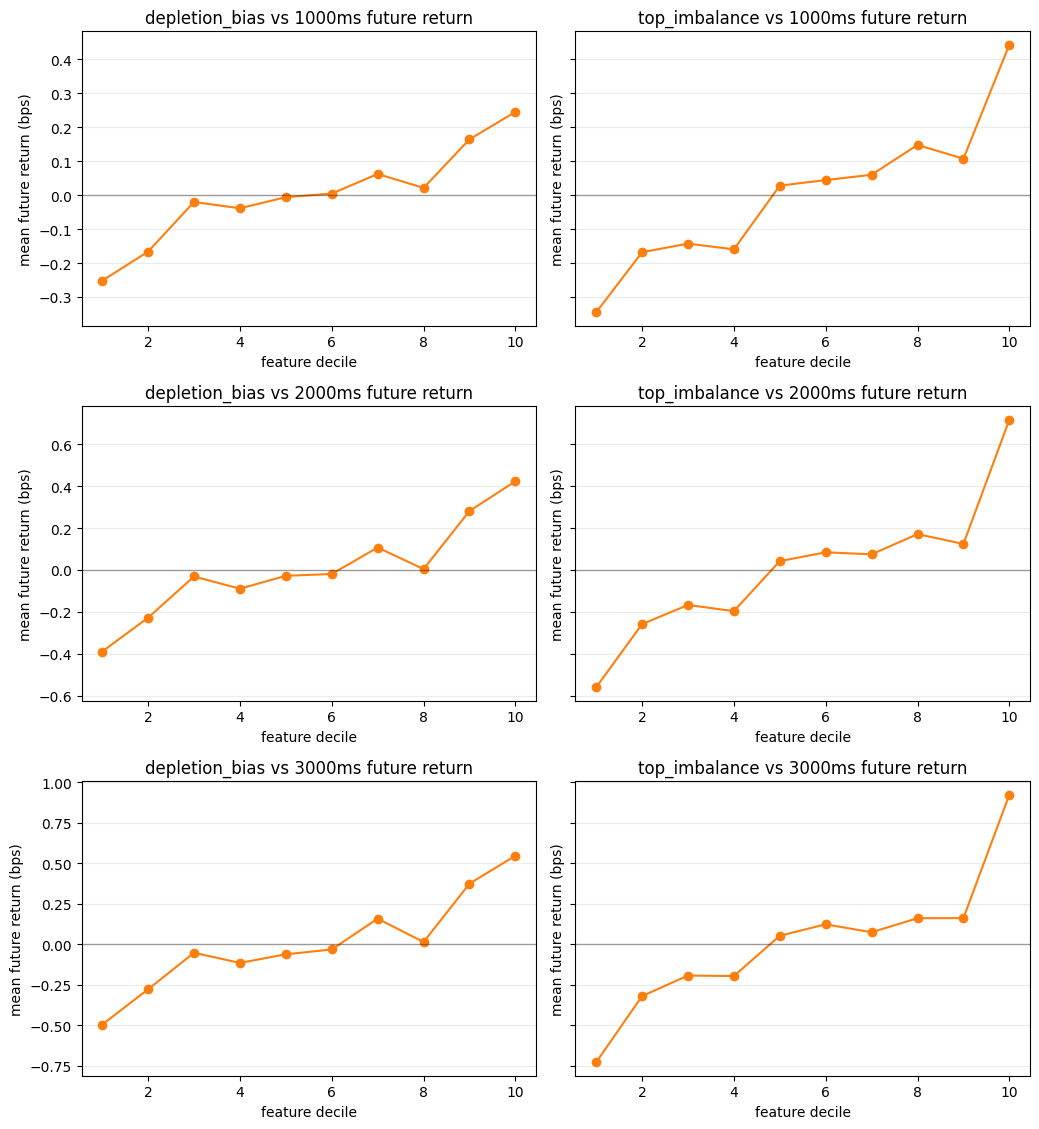

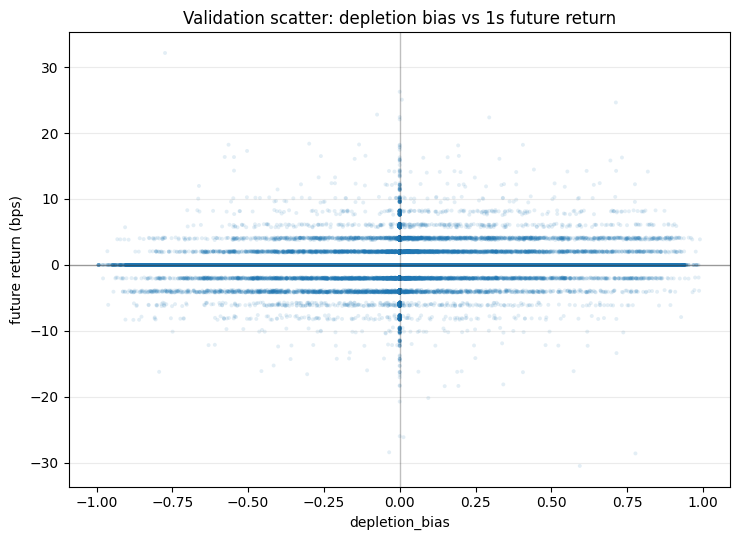

In [6]:
fig, axes = plt.subplots(len(HORIZONS_MS), 2, figsize=(10.5, 3.8 * len(HORIZONS_MS)), sharey='row')
if len(HORIZONS_MS) == 1:
    axes = np.array([axes])

for row_idx, horizon_ms in enumerate(HORIZONS_MS):
    target_col = f'fwd_ret_{horizon_ms}ms'
    for col_idx, feature_col in enumerate(['depletion_bias', 'top_imbalance']):
        ax = axes[row_idx, col_idx]
        grp = bucket_curve(valid_frame, feature_col=feature_col, target_col=target_col)
        if grp.empty:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
            continue
        ax.plot(grp['bucket'], grp[target_col] * 1e4, '-o', color='C1')
        ax.axhline(0.0, color='black', linewidth=1, alpha=0.35)
        ax.set_title(f'{feature_col} vs {horizon_ms}ms future return')
        ax.set_xlabel('feature decile')
        ax.set_ylabel('mean future return (bps)')
        ax.grid(True, axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 5.5))
scatter = valid_frame[['depletion_bias', 'fwd_ret_1000ms']].dropna().copy()
ax.scatter(scatter['depletion_bias'], scatter['fwd_ret_1000ms'] * 1e4, s=8, alpha=0.12, color='C0', edgecolors='none')
ax.axhline(0.0, color='black', linewidth=1, alpha=0.35)
ax.axvline(0.0, color='black', linewidth=1, alpha=0.25)
ax.set_title('Validation scatter: depletion bias vs 1s future return')
ax.set_xlabel('depletion_bias')
ax.set_ylabel('future return (bps)')
ax.grid(True, axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

,depletion_window,horizon_ms,model,n,r2,pearson,spearman,hit_rate
0,10s,1000,depletion_bias,80082,0.001674,0.041267,0.046285,0.106116
1,1s,1000,depletion_bias,80082,0.004774,0.069440,0.079387,0.109001
2,2s,1000,depletion_bias,80082,0.003903,0.062677,0.072137,0.109113
3,5s,1000,depletion_bias,80082,0.002934,0.054605,0.058607,0.107402
4,10s,1000,top+depletion_bias,80082,0.011827,0.108822,0.125102,0.121276
5,1s,1000,top+depletion_bias,80082,0.013213,0.114955,0.132526,0.122862
6,2s,1000,top+depletion_bias,80082,0.012693,0.112676,0.130154,0.122812
7,5s,1000,top+depletion_bias,80082,0.012255,0.110726,0.127496,0.122337
8,10s,2000,depletion_bias,80082,0.002713,0.052685,0.062049,0.155640
9,1s,2000,depletion_bias,80082,0.006161,0.079175,0.092915,0.158026


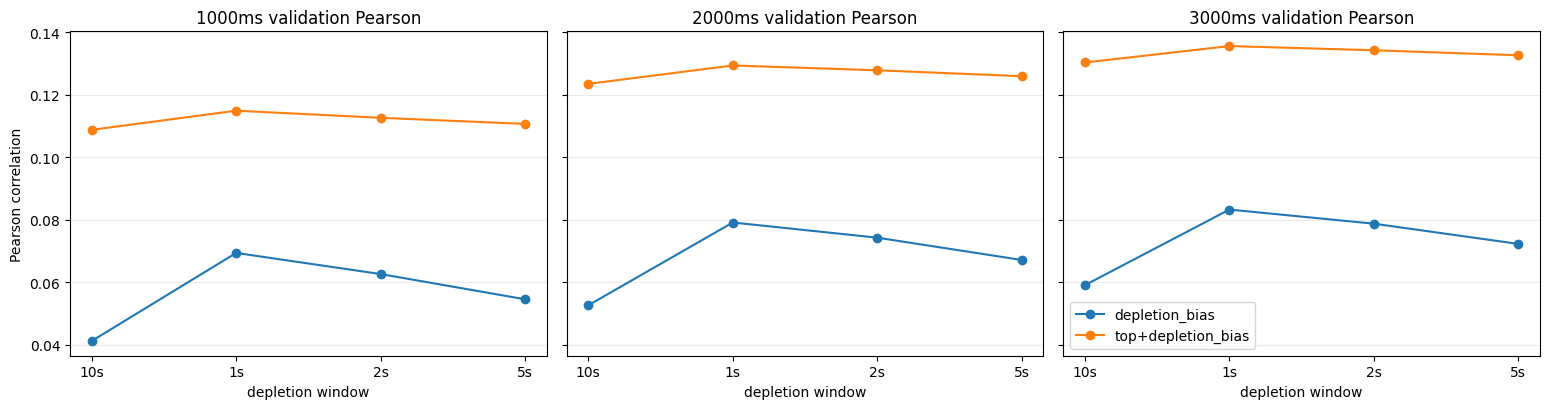

In [7]:
window_rows = []
for depletion_window in WINDOW_SWEEP:
    window_day_records = []
    for split_name, days in DAY_SPLITS.items():
        for day in days:
            frame, _summary = build_day_frame(day, split_name, depletion_window=depletion_window)
            window_day_records.append({'day': day, 'split': split_name, 'frame': frame})

    window_train = pd.concat([r['frame'] for r in window_day_records if r['split'] == 'train'], ignore_index=True)
    window_valid = pd.concat([r['frame'] for r in window_day_records if r['split'] == 'valid'], ignore_index=True)

    for horizon_ms in HORIZONS_MS:
        target_col = f'fwd_ret_{horizon_ms}ms'
        beta = fit_ols_beta(window_train, target_col, ['depletion_bias'])
        eval_frame, pred = ols_predict(window_valid, target_col, ['depletion_bias'], beta)
        metrics = ols_metrics(eval_frame[target_col].to_numpy(dtype=float), pred)
        window_rows.append({
            'depletion_window': depletion_window,
            'horizon_ms': horizon_ms,
            'model': 'depletion_bias',
            **metrics,
        })

        beta_combo = fit_ols_beta(window_train, target_col, ['top_imbalance', 'depletion_bias'])
        eval_frame_combo, pred_combo = ols_predict(window_valid, target_col, ['top_imbalance', 'depletion_bias'], beta_combo)
        metrics_combo = ols_metrics(eval_frame_combo[target_col].to_numpy(dtype=float), pred_combo)
        window_rows.append({
            'depletion_window': depletion_window,
            'horizon_ms': horizon_ms,
            'model': 'top+depletion_bias',
            **metrics_combo,
        })

window_summary = pd.DataFrame(window_rows).sort_values(['horizon_ms', 'model', 'depletion_window']).reset_index(drop=True)
display(window_summary.style.format({
    'r2': '{:.6f}',
    'pearson': '{:.6f}',
    'spearman': '{:.6f}',
    'hit_rate': '{:.6f}',
}))

fig, axes = plt.subplots(1, len(HORIZONS_MS), figsize=(5.2 * len(HORIZONS_MS), 4.2), sharey=True)
if len(HORIZONS_MS) == 1:
    axes = [axes]
for ax, horizon_ms in zip(axes, HORIZONS_MS):
    sub = window_summary[(window_summary['horizon_ms'] == horizon_ms) & (window_summary['model'] == 'depletion_bias')].sort_values('depletion_window')
    ax.plot(sub['depletion_window'], sub['pearson'], '-o', color='C0', label='depletion_bias')
    sub_combo = window_summary[(window_summary['horizon_ms'] == horizon_ms) & (window_summary['model'] == 'top+depletion_bias')].sort_values('depletion_window')
    ax.plot(sub_combo['depletion_window'], sub_combo['pearson'], '-o', color='C1', label='top+depletion_bias')
    ax.set_title(f'{horizon_ms}ms validation Pearson')
    ax.set_xlabel('depletion window')
    ax.grid(True, axis='y', alpha=0.25)
axes[0].set_ylabel('Pearson correlation')
axes[-1].legend(loc='best')
plt.tight_layout()
plt.show()

,horizon_ms,model,n,r2,pearson,spearman,hit_rate
0,1000,depletion_ratio,80082,0.005771,0.076013,0.081006,0.109113
1,1000,top+trade_adjusted_depletion,80082,0.013673,0.116944,0.131512,0.121875
2,1000,trade_adjusted_depletion,80082,0.004116,0.064243,0.070305,0.107902
3,1000,trade_flow_imbalance,80082,0.000895,0.030012,0.023427,0.099748
4,2000,depletion_ratio,80082,0.007255,0.085564,0.094546,0.157926
5,2000,top+trade_adjusted_depletion,80082,0.017344,0.131746,0.148684,0.173335
6,2000,trade_adjusted_depletion,80082,0.005441,0.074422,0.085138,0.156977
7,2000,trade_flow_imbalance,80082,0.000690,0.026717,0.017929,0.143740
8,3000,depletion_ratio,80082,0.007817,0.088906,0.101939,0.192478
9,3000,top+trade_adjusted_depletion,80082,0.018847,0.137318,0.159402,0.210185


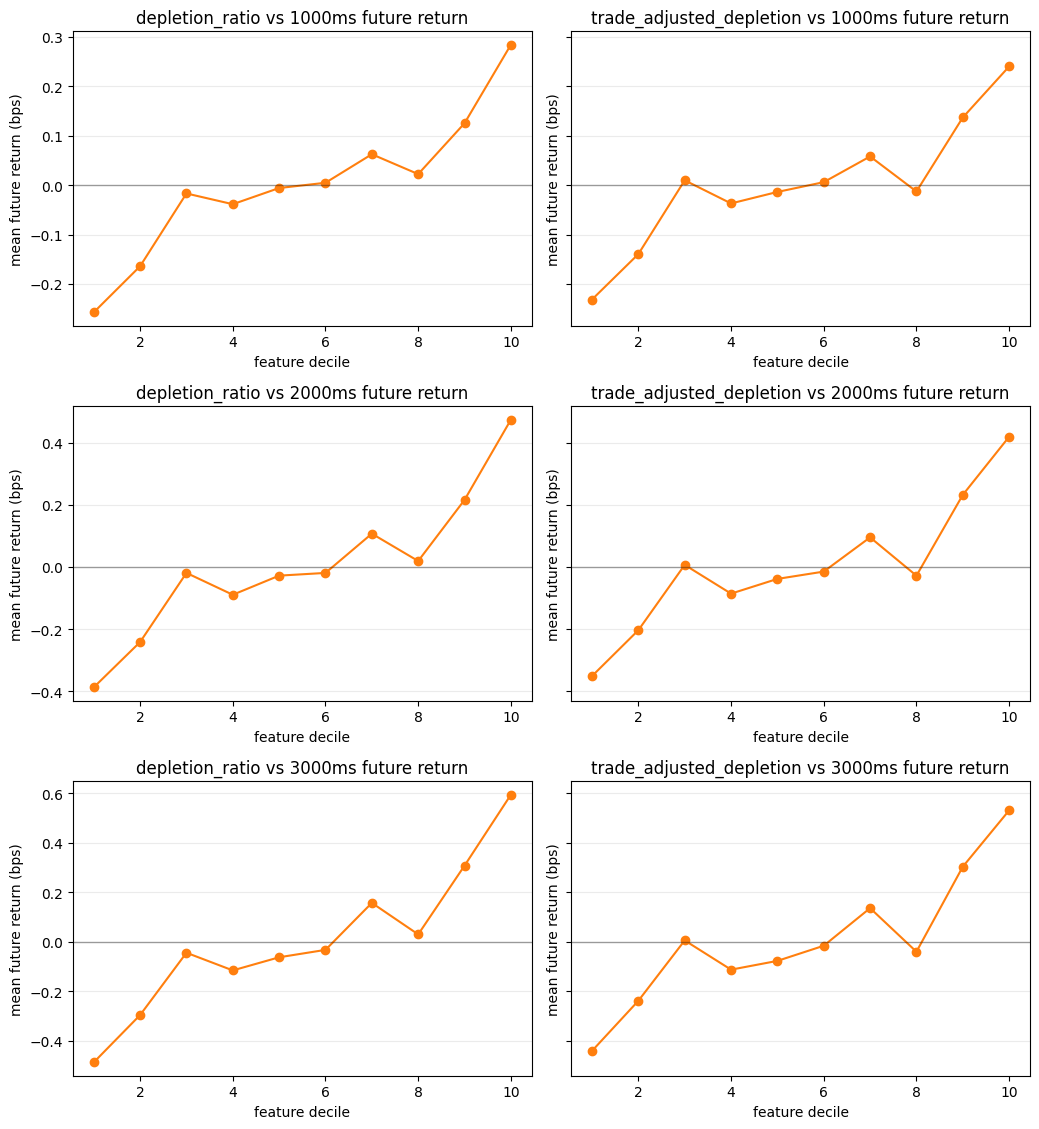

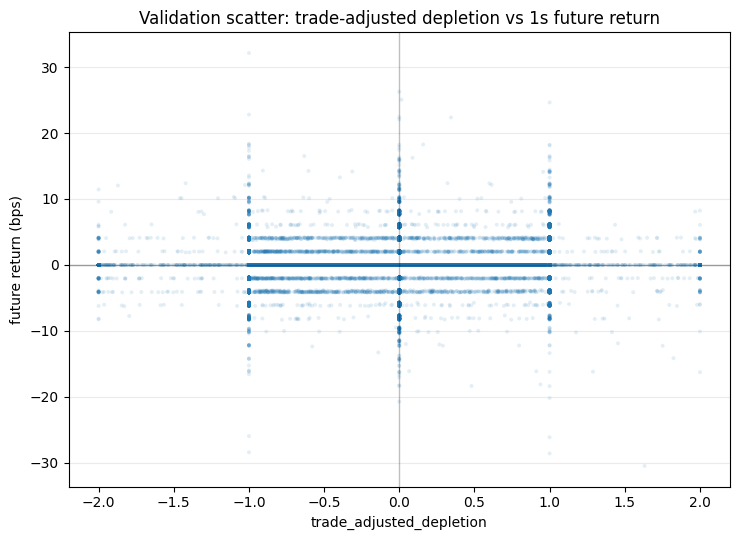

In [8]:
trade_rows = []
for horizon_ms in HORIZONS_MS:
    target_col = f'fwd_ret_{horizon_ms}ms'
    for feature_col, feature_name in [
        ('depletion_ratio', 'depletion_ratio'),
        ('trade_flow_imbalance', 'trade_flow_imbalance'),
        ('quote_update_intensity', 'quote_update_intensity'),
    ]:
        beta = fit_ols_beta(train_frame, target_col, [feature_col])
        eval_frame, pred = ols_predict(valid_frame, target_col, [feature_col], beta)
        metrics = ols_metrics(eval_frame[target_col].to_numpy(dtype=float), pred)
        trade_rows.append({
            'horizon_ms': horizon_ms,
            'model': feature_name,
            **metrics,
        })

    beta_combo = fit_ols_beta(train_frame, target_col, ['top_imbalance', 'quote_update_intensity'])
    eval_frame_combo, pred_combo = ols_predict(valid_frame, target_col, ['top_imbalance', 'quote_update_intensity'], beta_combo)
    metrics_combo = ols_metrics(eval_frame_combo[target_col].to_numpy(dtype=float), pred_combo)
    trade_rows.append({
        'horizon_ms': horizon_ms,
        'model': 'top+quote_update_intensity',
        **metrics_combo,
    })

trade_summary = pd.DataFrame(trade_rows).sort_values(['horizon_ms', 'model']).reset_index(drop=True)
display(trade_summary.style.format({
    'r2': '{:.6f}',
    'pearson': '{:.6f}',
    'spearman': '{:.6f}',
    'hit_rate': '{:.6f}',
}))

fig, axes = plt.subplots(len(HORIZONS_MS), 2, figsize=(10.5, 3.8 * len(HORIZONS_MS)), sharey='row')
if len(HORIZONS_MS) == 1:
    axes = np.array([axes])
for row_idx, horizon_ms in enumerate(HORIZONS_MS):
    target_col = f'fwd_ret_{horizon_ms}ms'
    for col_idx, feature_col in enumerate(['depletion_ratio', 'quote_update_intensity']):
        ax = axes[row_idx, col_idx]
        grp = bucket_curve(valid_frame, feature_col=feature_col, target_col=target_col)
        if grp.empty:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
            continue
        ax.plot(grp['bucket'], grp[target_col] * 1e4, '-o', color='C1')
        ax.axhline(0.0, color='black', linewidth=1, alpha=0.35)
        ax.set_title(f'{feature_col} vs {horizon_ms}ms future return')
        ax.set_xlabel('feature decile')
        ax.set_ylabel('mean future return (bps)')
        ax.grid(True, axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 5.5))
scatter = valid_frame[['quote_update_intensity', 'fwd_ret_1000ms']].dropna().copy()
ax.scatter(scatter['quote_update_intensity'], scatter['fwd_ret_1000ms'] * 1e4, s=8, alpha=0.12, color='C0', edgecolors='none')
ax.axhline(0.0, color='black', linewidth=1, alpha=0.35)
ax.axvline(0.0, color='black', linewidth=1, alpha=0.25)
ax.set_title('Validation scatter: quote update intensity vs 1s future return')
ax.set_xlabel('quote_update_intensity')
ax.set_ylabel('future return (bps)')
ax.grid(True, axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
plot_features = [
    'depletion_bias',
    'depletion_ratio',
    'queue_survival_half_life_ms',
    'queue_survival_bias_ms',
]
target_col = 'fwd_ret_1000ms'

fig, axes = plt.subplots(len(plot_features), 3, figsize=(18, 3.8 * len(plot_features)))
if len(plot_features) == 1:
    axes = np.array([axes])

for row_idx, feature_col in enumerate(plot_features):
    sub = valid_frame[[feature_col, target_col]].dropna().copy()
    feature = sub[feature_col].to_numpy(dtype=float)
    future_bps = sub[target_col].to_numpy(dtype=float) * 1e4

    ax_hist = axes[row_idx, 0]
    if feature.size:
        ax_hist.hist(feature, bins=80, color='C0', alpha=0.8, density=True)
    ax_hist.axvline(0.0, color='black', linewidth=1, alpha=0.35)
    ax_hist.set_title(f'{feature_col} histogram')
    ax_hist.set_xlabel(feature_col)
    ax_hist.set_ylabel('density')
    ax_hist.grid(True, axis='y', alpha=0.2)

    ax_scatter = axes[row_idx, 1]
    ax_scatter.scatter(feature, future_bps, s=6, alpha=0.12, color='C1', edgecolors='none')
    ax_scatter.axhline(0.0, color='black', linewidth=1, alpha=0.35)
    ax_scatter.set_title(f'{feature_col} vs 1s future return')
    ax_scatter.set_xlabel(feature_col)
    ax_scatter.set_ylabel('future return (bps)')
    ax_scatter.grid(True, axis='y', alpha=0.2)

    ax_bucket = axes[row_idx, 2]
    grp = bucket_curve(valid_frame, feature_col=feature_col, target_col=target_col)
    if grp.empty:
        ax_bucket.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax_bucket.transAxes)
        ax_bucket.set_axis_off()
    else:
        ax_bucket.plot(grp['bucket'], grp[target_col] * 1e4, '-o', color='C2')
        ax_bucket.axhline(0.0, color='black', linewidth=1, alpha=0.35)
        ax_bucket.set_title(f'{feature_col} deciles vs 1s future return')
        ax_bucket.set_xlabel('feature decile')
        ax_bucket.set_ylabel('mean future return (bps)')
        ax_bucket.grid(True, axis='y', alpha=0.25)

plt.tight_layout()
plt.show()


## How To Read The Output

- `depletion_bias` is positive when ask-side visible depth is shrinking faster than bid-side visible depth.
- `depletion_ratio` rescales that asymmetry by total depletion activity, so it emphasizes balance over magnitude.
- `depletion_acceleration` is the one-step change in `depletion_bias`, so it captures whether pressure is building or fading.
- `trade_flow_imbalance` is the signed trade-pressure proxy on the same `1s` grid.
- `quote_update_intensity` counts recent book-state changes over the same `1s` window, so it measures churn and instability.
- `queue_survival_half_life_ms` is a causal quote-age proxy for how long the current best bid / ask prices have persisted.
- `queue_survival_bias_ms` is the ask-minus-bid version of that age proxy, so it captures side asymmetry in persistence.
- If the validation `R^2` and bucket curves are weak, the feature is probably better treated as a regime indicator than a standalone predictor.
- `top+quote_update_intensity` tells you whether churn adds anything on top of the basic top-of-book imbalance baseline.
- `top+queue_survival_half_life_ms` and `top+queue_survival_bias_ms` tell you whether persistence adds anything on top of the same baseline.
- The new histogram/scatter/bucket block is the quickest way to inspect the depletion features visually.
- The bucket curves are the most useful quick check: monotone curves are easier to use than noisy scatter alone.
